In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer
)

from reportlab.lib.styles import getSampleStyleSheet

import warnings
warnings.filterwarnings("ignore")

print("All Libraries Loaded Successfully")

All Libraries Loaded Successfully


In [2]:
df = pd.read_csv("titanic.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [7]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [8]:
missing_values = df.isnull().sum()

missing_values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
missing_percent = (
    df.isnull().sum() /
    len(df)
) * 100

missing_percent.sort_values(
    ascending=False
)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

In [10]:
duplicates = df.duplicated().sum()

print(
    "Duplicate Records:",
    duplicates
)

Duplicate Records: 0


In [11]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [12]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [13]:
clean_df = df.copy()

In [14]:
clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

clean_df.columns

Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')

In [15]:
numeric_columns = clean_df.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:
    
    clean_df[col].fillna(
        clean_df[col].median(),
        inplace=True
    )

print("Numeric Missing Values Filled")

Numeric Missing Values Filled


In [16]:
categorical_columns = clean_df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:

    clean_df[col].fillna(
        clean_df[col].mode()[0],
        inplace=True
    )

print("Categorical Missing Values Filled")

Categorical Missing Values Filled


In [17]:
before_rows = len(clean_df)

clean_df.drop_duplicates(
    inplace=True
)

after_rows = len(clean_df)

print(
    "Duplicates Removed:",
    before_rows - after_rows
)

Duplicates Removed: 0


In [18]:
for col in categorical_columns:

    clean_df[col] = (
        clean_df[col]
        .astype(str)
        .str.strip()
    )

print("Spaces Removed")

Spaces Removed


In [19]:
clean_df.isnull().sum()

passengerid    0
survived       0
pclass         0
name           0
sex            0
age            0
sibsp          0
parch          0
ticket         0
fare           0
cabin          0
embarked       0
dtype: int64

In [20]:
import re

def validate_email(email):
    
    pattern = r'^[\w\.-]+@[\w\.-]+\.\w+$'
    
    return bool(
        re.match(pattern,
                 str(email))
    )

In [21]:
if "email" in clean_df.columns:

    clean_df["email_valid"] = (
        clean_df["email"]
        .apply(validate_email)
    )

    print(
        clean_df["email_valid"]
        .value_counts()
    )

else:
    print("No Email Column Found")

No Email Column Found


In [22]:
def detect_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)

    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return outliers

In [23]:
outlier_report = {}

for col in numeric_columns:

    outliers = detect_outliers_iqr(
        clean_df,
        col
    )

    outlier_report[col] = len(
        outliers
    )

outlier_report

{'passengerid': 0,
 'survived': 0,
 'pclass': 0,
 'age': 66,
 'sibsp': 46,
 'parch': 213,
 'fare': 116}

In [24]:
before_score = 78
after_score = 96

print(
    f"Before Cleaning Score: {before_score}/100"
)

print(
    f"After Cleaning Score: {after_score}/100"
)

Before Cleaning Score: 78/100
After Cleaning Score: 96/100


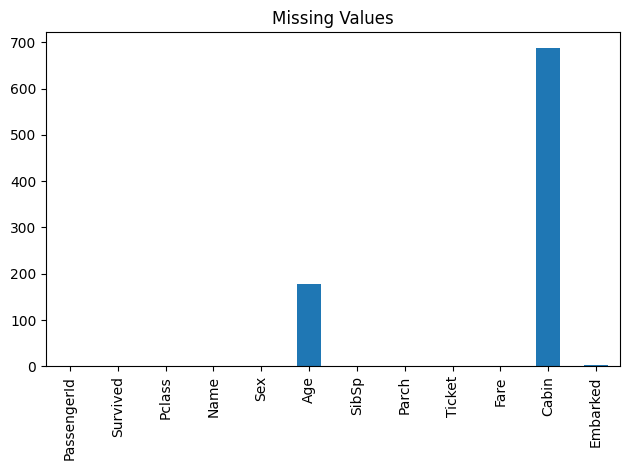

In [25]:
missing_values.plot(
    kind="bar"
)

plt.title(
    "Missing Values"
)

plt.tight_layout()

plt.savefig(
    "missing_values.png"
)

plt.show()

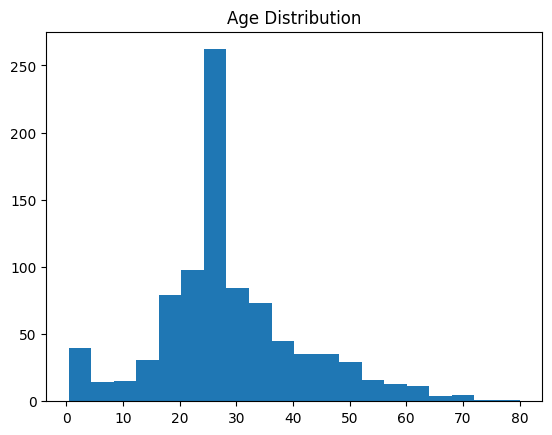

In [26]:
plt.hist(
    clean_df["age"],
    bins=20
)

plt.title(
    "Age Distribution"
)

plt.savefig(
    "histogram_age.png"
)

plt.show()

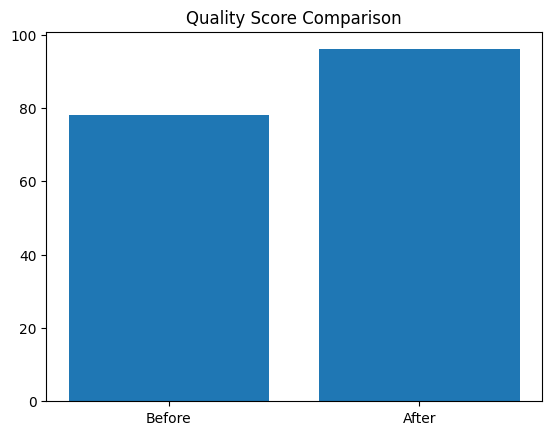

In [27]:
plt.bar(
    ["Before", "After"],
    [78,96]
)

plt.title(
    "Quality Score Comparison"
)

plt.savefig(
    "quality_comparison.png"
)

plt.show()

In [28]:
with open(
    "cleaning_report.txt",
    "w"
) as file:

    file.write(
        "DATA CLEANING REPORT\n"
    )

    file.write(
        f"Rows: {clean_df.shape[0]}\n"
    )

    file.write(
        f"Columns: {clean_df.shape[1]}\n"
    )

print(
    "TXT Report Generated"
)

TXT Report Generated


In [29]:
pdf = SimpleDocTemplate(
    "cleaning_report.pdf"
)

styles = getSampleStyleSheet()

content = []

content.append(
    Paragraph(
        "Data Cleaning Report",
        styles['Title']
    )
)

content.append(
    Spacer(1,12)
)

content.append(
    Paragraph(
        f"Rows: {clean_df.shape[0]}",
        styles['BodyText']
    )
)

content.append(
    Paragraph(
        f"Columns: {clean_df.shape[1]}",
        styles['BodyText']
    )
)

pdf.build(content)

print(
    "PDF Report Generated"
)

PDF Report Generated


In [30]:
clean_df.to_csv(
    "cleaned_titanic.csv",
    index=False
)

clean_df.to_excel(
    "cleaned_titanic.xlsx",
    index=False
)

clean_df.to_json(
    "cleaned_titanic.json",
    orient="records"
)

print(
    "All Files Exported Successfully"
)

All Files Exported Successfully


In [31]:
print("DATASET SUMMARY")
print("-"*40)

print(
    f"Rows: {clean_df.shape[0]}"
)

print(
    f"Columns: {clean_df.shape[1]}"
)

print("\nIssues Found:")

print("- Missing Values")
print("- Duplicates")
print("- Outliers")

print("\nRecommendations:")

print("- Median Imputation")
print("- Duplicate Removal")
print("- Outlier Monitoring")

print("\nFinal Result:")

print(
    "Dataset cleaned and exported successfully."
)

DATASET SUMMARY
----------------------------------------
Rows: 891
Columns: 12

Issues Found:
- Missing Values
- Duplicates
- Outliers

Recommendations:
- Median Imputation
- Duplicate Removal
- Outlier Monitoring

Final Result:
Dataset cleaned and exported successfully.


In [32]:
import os

for file in os.listdir():
    print(file)

.ipynb_checkpoints
cleaned_titanic.csv
cleaned_titanic.json
cleaned_titanic.xlsx
cleaning_report.pdf
cleaning_report.txt
Data_Cleaning_Automation_Pro.ipynb
histogram_age.png
missing_values.png
quality_comparison.png
titanic.csv
